Settings file (settings.yaml)

In [1]:
product_A_assumptions = {
    "age": 35,
    "premium": 500,
    "claims_amount": 500000,
    "policyholder_count": 1000,
    "projection_years": 20,
    "interest_rate": 0.05,
    "lapse_vector": [0.1, 0.08] + [0.05]*18,
    "expenses": {
        "commission": 150,
        "maintenance": 50
    },
    "inflation_rate": 0.02
}

product_B_assumptions = {
    "age": 35,
    "premium": 500,
    "claims_amount": 500000,
    "policyholder_count": 1000,
    "projection_years": 20,
    "interest_rate": 0.03,
    "lapse_vector": [0.2, 0.15] + [0.10]*18,
    "expenses": {
        "commission": 100,
        "maintenance": 40
    },
    "inflation_rate": 0.02,
}

product_C_assumptions = {
  "age": 45,
  "premium": 800,
  "claims_amount": 500000,
  "policyholder_count": 1000,
  "projection_years": 20,
  "interest_rate": 0.05,
  "inflation_rate": 0.02,
  "expenses": {
    "commission": 100,
    "maintenance": 50
  },
  "lapse_vector": [0.2, 0.15] + [0.10]*18,
}

Loading data (data_loader.py)

In [2]:
import pandas as pd
from pathlib import Path

# Loads data from provided VBT Excel file and creates a map of Age/Policy duration -> Mortality
def load_mortality_data(file_name, sheet_name):

  data_dir = Path("C:/Users/paula/PythonCoding/life_insurance/data")
  file_path = data_dir / file_name

  df_raw_vbt = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

  header_row_idx = df_raw_vbt[df_raw_vbt[0] == r"Row\Column"].index[0]
  df_vbt = pd.read_excel(file_path, sheet_name=sheet_name, header = header_row_idx)

  df_vbt = df_vbt.rename(columns={r"Row\Column": "Issue_Age"})
  df_vbt = df_vbt[pd.to_numeric(df_vbt["Issue_Age"], errors='coerce').notnull()]

  df_vbt["Issue_Age"] = df_vbt["Issue_Age"].astype(int)
  df_vbt = df_vbt.dropna()

  df_long = df_vbt.melt(
    id_vars=["Issue_Age"],
    var_name="Duration",
    value_name="Mortality_Rate"
  )

  df_long["Duration"] = pd.to_numeric(df_long["Duration"], errors='coerce')
  # Convert Mortality_Rate to numeric type
  df_long["Mortality_Rate"] = pd.to_numeric(df_long["Mortality_Rate"], errors='coerce')

  mortality_map = df_long.set_index(["Issue_Age", "Duration"])["Mortality_Rate"].to_dict()

  print(f"Loading data from {file_name}...")
  return mortality_map

file_name = input("Enter file name: ")
sheet_name = input("Enter sheet name")

mortality_lookup = load_mortality_data(file_name, sheet_name)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\paula\\PythonCoding\\life_insurance\\data\\VBT_2015'

Actuarial Engine (engine.py)

        POLICY FINANCIAL SUMMARY        
Metric                    |        Value
----------------------------------------
PV Premiums               | $4,207,806.15
PV Claims                 | $2,517,958.39
PV Expenses               | $629,109.74
----------------------------------------
Net Present Value (NPV)   | $1,060,738.02
Profit Margin             |        25.2%
        POLICY FINANCIAL SUMMARY        
Metric                    |        Value
----------------------------------------
PV Premiums               | $3,196,027.04
PV Claims                 | $1,677,387.83
PV Expenses               | $385,329.51
----------------------------------------
Net Present Value (NPV)   | $1,133,309.69
Profit Margin             |        35.5%


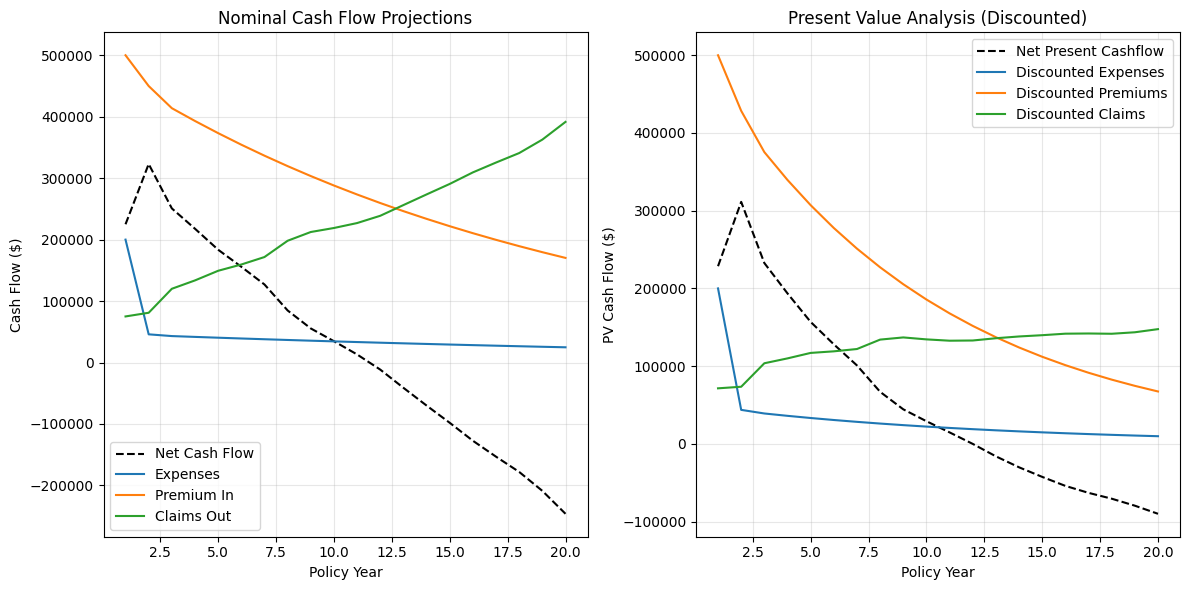

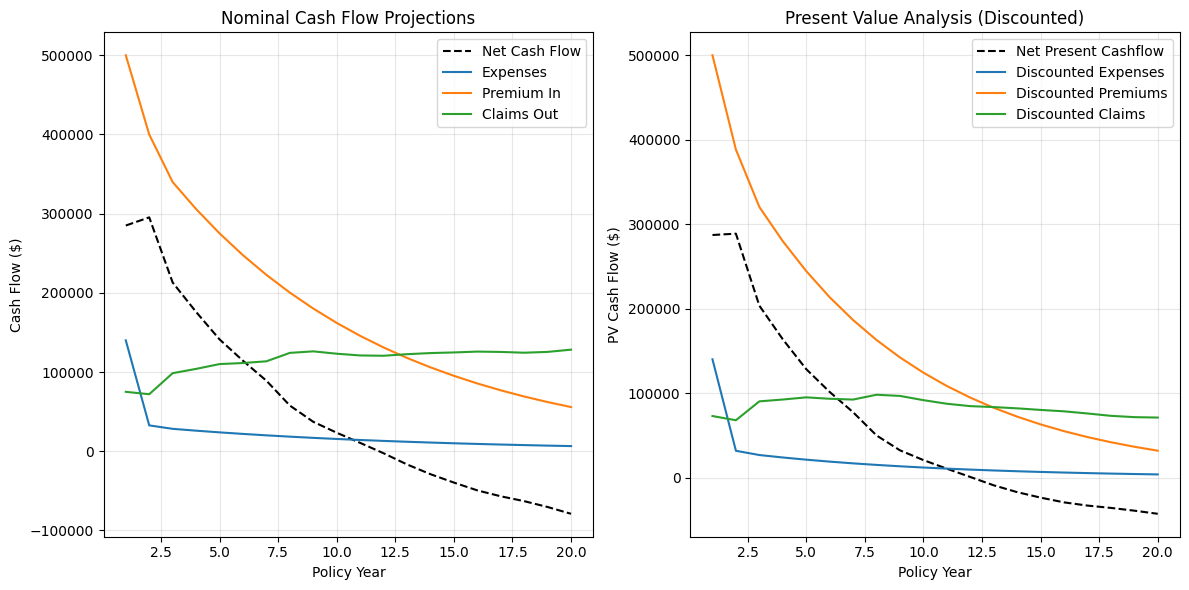

In [ ]:
import numpy as np
from scipy.optimize import brentq
from dataclasses import dataclass
from numpy._core.numeric import isscalar


@dataclass
class ProjectionState:
    """
    Holds the state of the projection as NumPy arrays.
    Replaces the DataFrame.
    """
    # Dimensions
    term: int

    # Demographics
    lives_start: np.ndarray
    deaths: np.ndarray
    lapses: np.ndarray
    lives_end: np.ndarray

    # Financials
    premiums: np.ndarray = None
    claims: np.ndarray = None
    expenses: np.ndarray = None
    net_cashflow: np.ndarray = None

    # Valuation
    discount_factors: np.ndarray = None
    pv_cashflow: np.ndarray = None

    @classmethod
    def initialize(cls, term: int):
        """Creates empty arrays of zeros to start."""
        return cls(
            term=term,
            lives_start=np.zeros(term),
            deaths=np.zeros(term),
            lapses=np.zeros(term),
            lives_end=np.zeros(term)
        )


class LifePolicy:
    def __init__(self, mortality_map, assumptions):
        # Base assumptions from config dict
        self.age = assumptions["age"]
        self.premium = assumptions["premium"]
        self.claims = assumptions["claims_amount"]
        self.l0 = assumptions["policyholder_count"]

        self.projection_years = assumptions["projection_years"]
        self.interest_rate = assumptions["interest_rate"]
        self.lapse_rates = assumptions["lapse_vector"]
        self.expenses_comm = assumptions["expenses"]["commission"]
        self.expenses_maint = assumptions["expenses"]["maintenance"]
        self.inflation_rate = assumptions["inflation_rate"]

        self.mortality_map = mortality_map

    def _get_mortality_vector(self):
        return [self.mortality_map.get((self.age, d)) for d in range(1, self.projection_years + 1)]

    def _build_decrement_vectors(self):

        t_len = self.projection_years
        state = ProjectionState.initialize(t_len)

        current_lives = self.l0

        mortality_vec = self._get_mortality_vector()

        for t in range(t_len):
            state.lives_start[t] = current_lives

            q_d = mortality_vec[t]

            d_t = current_lives * q_d
            w_t = (current_lives - d_t) * self.lapse_rates[t]

            state.deaths[t] = d_t
            state.lapses[t] = w_t

            current_lives = current_lives - d_t - w_t
            state.lives_end[t] = current_lives

        return state

    def _calculate_cashflows(self, state: ProjectionState):
        state.premiums = state.lives_start * self.premium
        state.claims = state.deaths * self.claims

        inflation_index = np.power(1 + self.inflation_rate, np.arange(state.term))
        maint_exp = state.lives_start * self.expenses_maint * inflation_index

        acq_exp_total = (self.l0 * self.expenses_comm)
        maint_exp[0] += acq_exp_total

        state.expenses = maint_exp

        state.net_cashflow = state.premiums - state.claims - state.expenses

        return state


    def _apply_discounting(self, state: ProjectionState):
      
      if np.isscalar(self.interest_rate):
        rates_vector = np.full(state.term, self.interest_rate)
      else:
        rates_vector = np.array(self.interest_rate)

        if len(rates_vector) < state.term:
          raise ValueError("Length of interest rate vector does not match projection length.")

        rates_vector = rates_vector[:state.term]
      
      v_vector = 1 / (1 + rates_vector)

      discount_end = np.cumprod(v_vector)

      discount_start = np.empty_like(discount_end)
      discount_start[0] = 1.0
      discount_start[1:] = discount_end[:-1]

      state.discount_factors_start = discount_start
      state.discount_factors_end = discount_end

      pv_premiums = state.premiums * discount_start
      pv_claims = state.claims * discount_end
      pv_expenses = state.expenses * discount_start

      state.pv_cashflow = pv_premiums - pv_claims - pv_expenses

      return state


    def run(self) -> ProjectionState:

        state_step1 = self._build_decrement_vectors()
        state_step2 = self._calculate_cashflows(state_step1)
        self.final_state = self._apply_discounting(state_step2)

        return self.final_state


    def summary_metrics(self, verbose: bool = True) -> dict:

      if self.final_state is None:
        raise ValueError("Engine has not run yet. Call (run) first.")

      total_pv_premium = (self.final_state.premiums * self.final_state.discount_factors_start).sum()
      total_pv_claims = (self.final_state.claims * self.final_state.discount_factors_end).sum()
      total_pv_expenses = (self.final_state.expenses * self.final_state.discount_factors_start).sum()
      npv = self.final_state.pv_cashflow.sum()

      metrics = {
        "total_pv_premiums": total_pv_premium,
        "total_pv_claims": total_pv_claims,
        "total_pv_expenses": total_pv_expenses,
        "total_net_cashflow": self.final_state.net_cashflow.sum(),
        "npv": npv,
        "profit_margin": npv / total_pv_premium if total_pv_premium > 0 else 0.0
      }

      if verbose:
        print("=" * 40)
        print(f"{'POLICY FINANCIAL SUMMARY':^40}")
        print("=" * 40)
        print(f"{'Metric':<25} | {'Value':>12}")
        print("-" * 40)

        # Financials w
        print(f"{'PV Premiums':<25} | ${metrics['total_pv_premiums']:,.2f}")
        print(f"{'PV Claims':<25} | ${metrics['total_pv_claims']:,.2f}")
        print(f"{'PV Expenses':<25} | ${metrics['total_pv_expenses']:,.2f}")
        print("-" * 40)

        # Key Performance Indicators
        print(f"{'Net Present Value (NPV)':<25} | ${metrics['npv']:,.2f}")

        margin_label = "Profit Margin"
        print(f"{margin_label:<25} | {metrics['profit_margin']:>12.1%}")
        print("=" * 40)

      return metrics

    def plot_results(self):
      import matplotlib.pyplot as plt
      import seaborn as sns

      if self.final_state is None:
        print("Model not run yet.")
        return

      years = np.arange(1, self.projection_years + 1)
      st = self.final_state


      disc_premiums = st.premiums * st.discount_factors_start
      disc_expenses = st.expenses * st.discount_factors_start

      disc_claims = st.claims * st.discount_factors_end

      fig, ax = plt.subplots(1, 2, figsize=(12, 6))

      sns.lineplot(x=years, y=st.net_cashflow, label="Net Cash Flow", ax=ax[0], color="black", linestyle="--")
      sns.lineplot(x=years, y=st.expenses, label="Expenses", ax=ax[0])
      sns.lineplot(x=years, y=st.premiums, label="Premium In", ax=ax[0])
      sns.lineplot(x=years, y=st.claims, label="Claims Out", ax=ax[0])

      ax[0].set_title("Nominal Cash Flow Projections")
      ax[0].set_xlabel("Policy Year")
      ax[0].set_ylabel("Cash Flow ($)")
      ax[0].legend()
      ax[0].grid(True, alpha=0.3)


      sns.lineplot(x=years, y=st.pv_cashflow, label="Net Present Cashflow", ax=ax[1], color="black", linestyle="--")
      sns.lineplot(x=years, y=disc_expenses, label="Discounted Expenses", ax=ax[1])
      sns.lineplot(x=years, y=disc_premiums, label="Discounted Premiums", ax=ax[1])
      sns.lineplot(x=years, y=disc_claims, label="Discounted Claims", ax=ax[1])
      ax[1].legend()
      ax[1].set_title("Present Value Analysis (Discounted)")
      ax[1].set_xlabel("Policy Year")
      ax[1].set_ylabel("PV Cash Flow ($)")
      ax[1].grid(True, alpha=0.3)

      plt.tight_layout()
      plt.show()




class MarginOptimizer:
    def __init__(self, policy_prototype):
      self.policy = policy_prototype

    def _objective_function(self, premium_guess: float, target_margin: float) -> float:

      self.policy.premium = premium_guess
      self.policy.run()

      metrics = self.policy.summary_metrics(verbose=False)
      current_margin = metrics["profit_margin"]

      return current_margin - target_margin



    def solve_for_premium(self, target_margin: float = 0.07) -> float:

      low_bound = 1
      high_bound = 10000

      try:
        optimal_premium = brentq(
            f=self._objective_function,
            a=low_bound,
            b=high_bound,
            args=(target_margin,),
            xtol=1e-4,
        )
        print(f"Optimization Success! Found Premium: ${optimal_premium:,.2f}")
        return optimal_premium

      except RuntimeError as e:
        print(f"Optimization Failed: Target margin is impossible within bounds ($1 - $10k) {e}")
        return -1


pass

Main.py

In [ ]:
mortality_lookup = load_mortality_data("VBT_2015.xlsx", "Sheet1")


# policyA = LifePolicy(mortality_lookup, product_A_assumptions)
# policyA.run()

# policyA.summary_metrics(verbose=True)

# optimizerA = MarginOptimizer(policyA)
# optimizerA.solve_for_premium(target_margin=0.07)

policyB = LifePolicy(mortality_lookup, product_B_assumptions)
policyB.run()
policyB.summary_metrics(verbose=True)

MarginOptimizer(policyB).solve_for_premium(target_margin=0.07)

policyC = LifePolicy(mortality_lookup, product_C_assumptions)
policyC.run()
policyC.summary_metrics(verbose=True)

MarginOptimizer(policyC).solve_for_premium(target_margin=0.07)


pass

Optimization Success! Found Premium: $402.10
Optimization Success! Found Premium: $346.99


Sensitivity analysis

In [ ]:
product_A_assumptions = {
    "age": 35,
    "premium": 500,
    "claims_amount": 500000,
    "policyholder_count": 1000,
    "projection_years": 20,
    "interest_rate": 0.05,
    "lapse_vector": [0.1, 0.08] + [0.05]*18,
    "expenses": {
        "commission": 150,
        "maintenance": 50
    },
    "inflation_rate": 0.02
}


# print(modified_product_A_assumptions["lapse_vector"])

# claims_amount_modifier = 1.2

# modified_product_A_assumptions = product_A_assumptions.copy()
# modified_product_A_assumptions["claims_amount"] = modified_product_A_assumptions["claims_amount"] * claims_amount_modifier

# interest_rate_modifier = 0.8

# modified_product_A_assumptions = product_A_assumptions.copy()
# modified_product_A_assumptions["interest_rate"] = modified_product_A_assumptions["interest_rate"] * interest_rate_modifier

# policy_A = LifePolicy(mortality_lookup, product_A_assumptions)
# policy_A.run()
# policy_A.summary_metrics(verbose=True)

# MarginOptimizer(policy_A).solve_for_premium(target_margin=0.07)


# policy_A_modified = LifePolicy(mortality_lookup, modified_product_A_assumptions)
# policy_A_modified.run()
# policy_A_modified.summary_metrics(verbose=True)

# MarginOptimizer(policy_A_modified).solve_for_premium(target_margin=0.07)


lapse_rate_modifer = np.arange(0.5, 1.6, 0.1)

for mod in lapse_rate_modifer:
  print(f"Lapse rate modifier: {mod:.1f}")
  modified_product_A_assumptions = product_A_assumptions.copy()
  modified_product_A_assumptions["lapse_vector"] = [np.round(rate * mod, 3) for rate in modified_product_A_assumptions["lapse_vector"]]
  print(f"New lapse vector: {np.array(modified_product_A_assumptions["lapse_vector"][0:3])} ... {np.array(modified_product_A_assumptions["lapse_vector"][-1:])}")

  policy_A_modified = LifePolicy(mortality_lookup, modified_product_A_assumptions)
  policy_A_modified.run()
  print(f"New margin rate: {policy_A_modified.summary_metrics(verbose=False)["profit_margin"]:.2%}\n")

pass

Vasicek Model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class VasicekModel:
  def __init__(self, r0, kappa, theta, sigma, T=20, dt=1):
    self.r0 = r0
    self.kappa = kappa
    self.theta = theta
    self.sigma = sigma
    self.T = T
    self.dt = dt
    self.n_steps = int(T / dt)

  def generate_paths(self, n_paths):
    rates = np.zeros((n_paths, self.n_steps + 1))
    rates[:,0] = self.r0

    Z = np.random.normal(0, 1, (n_paths, self.n_steps))

    sqrt_dt = np.sqrt(self.dt)

    for t in range(self.n_steps):
      r_t = rates[:, t]
      drift = self.kappa * (self.theta - r_t) * self.dt

      shock = self.sigma * sqrt_dt * Z[:,t]

      rates[:, t+1] = r_t + drift + shock
    
    return rates


def calculate_stochastic_npv(policy_object, n_simulations=1000, verbose=True):

  vm = VasicekModel(r0=0.05, kappa=0.15, theta=0.04, sigma=0.015, T=20, dt=1)
  rate_paths = vm.generate_paths(n_simulations)

  npvs = []

  for i in range(n_simulations):
    path = rate_paths[i, :]

    policy_object.interest_rate = path
    policy_object.run()

    npv = policy_object.summary_metrics(verbose=False)["npv"]
    npvs.append(npv)

  mean_npv = np.mean(npvs)
  cte_90 = np.mean(sorted(npvs)[:int(n_simulations * 0.1)])
  cte_95 = np.mean(sorted(npvs)[:int(n_simulations * 0.05)])

  if verbose:
    print(f"Stochastic Mean NPV: {mean_npv:,.2f}")
    print(f"90% CTE: {cte_90:,.2f}")
    print(f"95% CTE: {cte_95:,.2f}")

  return npvs

policy_A_test = LifePolicy(mortality_lookup, product_A_assumptions)
calculate_stochastic_npv(policy_A_test)

policy_A = LifePolicy(mortality_lookup, product_A_assumptions)
policy_A.run()
policy_A.summary_metrics(verbose=True)

pass

Vasicek visualisation

In [ ]:
vasicek = VasicekModel(r0=0.05, kappa=0.15, theta=0.04, sigma=0.015, T=20, dt=1)

simulated_rates = vasicek.generate_paths(50)


fig, ax = plt.subplots(figsize=(10, 6))


sns.lineplot(data=simulated_rates.T,
             linestyle="-",
             dashes=False,
             palette="viridis",
             alpha=0.7,
             ax=ax,
             legend=False
             )
ax.axhline(y=vasicek.theta, color="k", ls="--", lw=1.5, label="Long Term Mean")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Interest Rate")
ax.set_title("Simulated Interest Rate Paths")
ax.set_ylim(-0.05, 0.15)
ax.set_xlim(0, vasicek.T)
ax.set_yticks(np.arange(-0.05, 0.16, 0.025))
ax.set_yticklabels([f"{label:.1%}" for label in ax.get_yticks()])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Tail Risk Visualisations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_risk_profile(npv_results):

    npvs = np.array(npv_results)
    n_sims = len(npvs)
    
    mean_npv = np.mean(npvs)
    

    sorted_npvs = np.sort(npvs)
    

    cutoff_index_90 = int(n_sims * 0.10)
    cutoff_index_95 = int(n_sims * 0.05)
    

    var_90 = sorted_npvs[cutoff_index_90]
    var_95 = sorted_npvs[cutoff_index_95]

    cte_90 = np.mean(sorted_npvs[:cutoff_index_90])
    cte_95 = np.mean(sorted_npvs[:cutoff_index_95])

    print(f"{'RISK METRICS':^30}")
    print("="*30)
    print(f"Mean NPV:      ${mean_npv:,.0f}")
    print(f"VaR 90%:       ${var_90:,.0f} (Threshold for worst 10%)")
    print(f"CTE 90%:       ${cte_90:,.0f} (Avg of worst 10%)")
    print(f"CTE 95%:       ${cte_95:,.0f} (Avg of worst 5%)")
    print("="*30)


    plt.figure(figsize=(12, 7))
    

    sns.histplot(npvs, kde=True, bins=50, color='skyblue', edgecolor='white', alpha=0.6, label='NPV Distribution')
    

    plt.axvline(mean_npv, color='black', linestyle='--', linewidth=2, label=f'Mean: ${mean_npv:,.0f}')
    plt.axvline(var_90, color='orange', linestyle='--', linewidth=2, label=f'VaR 90%: ${var_90:,.0f}')
    

    plt.axvspan(min(npvs), var_90, color='red', alpha=0.15, label='Tail Risk Area (Worst 10%)')


    plt.scatter([cte_90], [5], color='red', s=100, zorder=5, marker='X', label=f'CTE 90%: ${cte_90:,.0f}')

    plt.title('Stochastic NPV Distribution & Tail Risk Analysis', fontsize=14)
    plt.xlabel('Net Present Value ($)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


npv_results = calculate_stochastic_npv(policy_A_test, verbose=False) 
plot_risk_profile(npv_results)

"Funnel of Doubt" Visualization

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def visualize_funnel_and_distribution(rate_paths, npv_results):
    """
    Plots the Stochastic Dashboard:
    1. The 'Funnel of Doubt' (Rate Paths)
    2. The 'Risk Distribution' (Resulting NPVs)
    """
    

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Interest Rate Paths
    ax1 = axes[0]
    years = np.arange(rate_paths.shape[1])
    

    ax1.plot(years, rate_paths.T, color='steelblue', alpha=0.05, linewidth=1)
    
    # Ploting mean path
    mean_path = np.mean(rate_paths, axis=0)
    ax1.plot(years, mean_path, color='red', linewidth=3, linestyle='--', label='Mean Rate Path')
    
    # Plotting 5th and 95th percentile paths
    p05 = np.percentile(rate_paths, 5, axis=0)
    p95 = np.percentile(rate_paths, 95, axis=0)
    ax1.plot(years, p05, color='black', linewidth=1.5, linestyle=':', label='90% Confidence Interval')
    ax1.plot(years, p95, color='black', linewidth=1.5, linestyle=':')

    ax1.set_title("The 'Funnel of Doubt': 1,000 Interest Rate Scenarios", fontsize=12)
    ax1.set_xlabel("Projection Year")
    ax1.set_ylabel("Interest Rate")
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    

    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.1%}".format(x)))


    # NPV Histogram
    ax2 = axes[1]
    
    # Plot Histogram
    sns.histplot(npv_results, kde=True, ax=ax2, color='green', alpha=0.5, edgecolor='white')
    
    # Add Mean Line
    mean_npv = np.mean(npv_results)
    ax2.axvline(mean_npv, color='red', linestyle='--', linewidth=2, label=f'Mean NPV: ${mean_npv:,.0f}')
    
    ax2.set_title("Resulting Distribution of Profit (NPV)", fontsize=12)
    ax2.set_xlabel("Net Present Value ($)")
    ax2.set_ylabel("Frequency")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Generate the paths
vm = VasicekModel(r0=0.05, kappa=0.15, theta=0.04, sigma=0.015, T=20, dt=1)
paths = vm.generate_paths(1000)

# Calculating NPVs
npv_results = calculate_stochastic_npv(policy_A_test, n_simulations=1000)


visualize_funnel_and_distribution(paths, npv_results)